In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ID = "fyxical-poc"
DATASET    = "fyxical_poc"
client     = bigquery.Client(project=PROJECT_ID)

patients    = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_pathways`").to_dataframe()
exercises   = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.exercises`").to_dataframe()
predictions = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.model_predictions`").to_dataframe()

print(f"Patients    : {len(patients)}")
print(f"Exercises   : {len(exercises)}")
print(f"Predictions : {len(predictions)}")

Patients    : 500
Exercises   : 116
Predictions : 100


In [2]:
# Acronym reference

ACRONYMS_CLINICAL = {
    "OSW"  : "Oswestry Disability Index — 0-100% disability scale. "
              "Minimal 0-20% / Moderate 21-40% / Severe 41-60% / "
              "Crippled 61-80% / Bed-bound 81-100%.",
    "VAS"  : "Visual Analogue Scale — pain score 0-10. "
              "Mild 0-3 / Moderate 4-6 / Severe 7-10.",
    "KPI"  : "Key Performance Indicator — summary metrics for the POC.",
    "POC"  : "Proof of Concept — this project stage. Not validated for clinical use.",
    "IRB"  : "Institutional Review Board — ethics approval required before "
              "clinical deployment with real patients.",
    "HITL" : "Human-in-the-Loop — planned validation protocol where a licensed PT "
              "independently labels edge cases to provide clinician-derived ground truth.",
}

ACRONYMS_EXERCISES = {
    "BHF" : "Bilateral Hip Flexion / Low Back Flexion Stretch",
    "BR"  : "Bracing",
    "BRG" : "Bridging",
    "CHP" : "Child's Pose",
    "HF"  : "Hip Flexion",
    "HSE" : "Hip / Shoulder Extension",
    "LFT" : "Lift Training",
    "LME" : "Lumbar Extension Progression",
    "LTR" : "Lumbar Trunk Rotation",
    "LTS" : "Lateral Trunk Stretch",
    "PLC" : "Pelvic Tilt",
    "PLK" : "Plank",
    "PP"  : "Paloff Press",
    "QDS" : "Quadruped Stretches",
    "RSC" : "Rows with Stable Core",
    "SGA" : "Seated Glute Activation",
    "SK"  : "Single Knee to Chest (SKTC)",
    "THE" : "Thoracic Extension",
    "THR" : "Thoracic Rotation",
}

ACRONYMS_PATHWAYS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks",
    "ACUTE_SEVERE"   : "Acute + Severe         — Pain score 7-10, Duration <2 weeks",
    "SUBACUTE"       : "Subacute               — Duration 2-12 weeks, any severity",
    "CHRONIC"        : "Chronic / High Burden  — Duration >12 weeks OR high OSW disability",
}

print("=" * 65)
print("  ACRONYM REFERENCE — Notebook 05")
print("=" * 65)

print("\n── Clinical & Project Terms ────────────────────────────────")
for code, desc in ACRONYMS_CLINICAL.items():
    print(f"\n  {code}")
    words = desc.split()
    line = "    "
    for word in words:
        if len(line) + len(word) + 1 > 64:
            print(line)
            line = "    " + word + " "
        else:
            line += word + " "
    print(line.rstrip())

print("\n── Pathway Codes ───────────────────────────────────────────")
for code, desc in ACRONYMS_PATHWAYS.items():
    print(f"  {code:<16} {desc}")

print("\n── Exercise Group Codes (all 19) ───────────────────────────")
for code, desc in ACRONYMS_EXERCISES.items():
    print(f"  {code:<5} {desc}")

print("\n" + "=" * 65)

  ACRONYM REFERENCE — Notebook 05

── Clinical & Project Terms ────────────────────────────────

  OSW
    Oswestry Disability Index — 0-100% disability scale. 
    Minimal 0-20% / Moderate 21-40% / Severe 41-60% / Crippled 
    61-80% / Bed-bound 81-100%.

  VAS
    Visual Analogue Scale — pain score 0-10. Mild 0-3 / 
    Moderate 4-6 / Severe 7-10.

  KPI
    Key Performance Indicator — summary metrics for the POC.

  POC
    Proof of Concept — this project stage. Not validated for 
    clinical use.

  IRB
    Institutional Review Board — ethics approval required 
    before clinical deployment with real patients.

  HITL
    Human-in-the-Loop — planned validation protocol where a 
    licensed PT independently labels edge cases to provide 
    clinician-derived ground truth.

── Pathway Codes ───────────────────────────────────────────
  ACUTE_MILD_MOD   Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks
  ACUTE_SEVERE     Acute + Severe         — Pain score 7-10, Duration 

In [3]:
# KPI Scoreboard

PATHWAY_LABELS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  (Pain 0-6, Duration <2 wks)",
    "ACUTE_SEVERE"   : "Acute + Severe         (Pain 7-10, Duration <2 wks)",
    "SUBACUTE"       : "Subacute               (Duration 2-12 wks, any severity)",
    "CHRONIC"        : "Chronic / High Burden  (Duration >12 wks OR high OSW)",
}

PATHWAY_EXERCISES = {
    "ACUTE_MILD_MOD" : ["BHF", "SK", "CHP", "LTR", "LTS", "PLC"],
    "ACUTE_SEVERE"   : ["BHF", "SK", "PLC", "SGA", "LME"],
    "SUBACUTE"       : ["PLC", "BRG", "BR", "HSE", "QDS", "THE", "THR"],
    "CHRONIC"        : ["BR", "PLK", "PP", "RSC", "LFT", "HF", "LME", "THE", "THR"],
}

total_patients   = len(patients)
pathway_counts   = patients["recommended_pathway"].value_counts()
accuracy         = predictions["prediction_correct"].mean()
covered_pathways = patients["recommended_pathway"].nunique()

print("=" * 58)
print("  FYXICAL POC — KPI SCOREBOARD")
print("=" * 58)
print(f"  Total patients processed    : {total_patients}")
print(f"  Pathways assigned           : {covered_pathways}")
print(f"  Model accuracy (rule agree) : {accuracy*100:.1f}%  [test set n=100]")
print(f"  Note: accuracy = rule-agreement on held-out set, NOT clinical validity")
print(f"  Exercise groups in library  : {exercises['Category_Code'].nunique()}")
print(f"  Total exercise records      : {len(exercises)}")
print("=" * 58)
print()
for pathway, count in pathway_counts.items():
    pct      = count / total_patients * 100
    label    = PATHWAY_LABELS.get(pathway, pathway)
    n_groups = len(PATHWAY_EXERCISES.get(pathway, []))
    print(f"  {label}")
    print(f"    {count} patients ({pct:.1f}%)  |  {n_groups} exercise groups assigned")
    print()

  FYXICAL POC — KPI SCOREBOARD
  Total patients processed    : 500
  Pathways assigned           : 4
  Model accuracy (rule agree) : 81.0%  [test set n=100]
  Note: accuracy = rule-agreement on held-out set, NOT clinical validity
  Exercise groups in library  : 19
  Total exercise records      : 116

  Chronic / High Burden  (Duration >12 wks OR high OSW)
    296 patients (59.2%)  |  9 exercise groups assigned

  Acute + Severe         (Pain 7-10, Duration <2 wks)
    76 patients (15.2%)  |  5 exercise groups assigned

  Subacute               (Duration 2-12 wks, any severity)
    67 patients (13.4%)  |  7 exercise groups assigned

  Acute + Mild/Moderate  (Pain 0-6, Duration <2 wks)
    61 patients (12.2%)  |  6 exercise groups assigned



In [4]:
# Full Patient-Exercise Output

pathway_rows = []
for pathway, codes in PATHWAY_EXERCISES.items():
    for code in codes:
        pathway_rows.append({"recommended_pathway": pathway, "Category_Code": code})
pathway_exercise_map = pd.DataFrame(pathway_rows)

patient_output = (
    patients[["patient_id","recommended_pathway","pathway_label",
              "pain_severity_category","osw_baseline_disability_category",
              "pain_duration_category","pain_duration_weeks",
              "pain_severity_score_0_10","osw_baseline_percent_disability"]]
    .merge(pathway_exercise_map, on="recommended_pathway", how="left")
    .merge(
        exercises[["Exercise_ID","Exercise name","Category_Code","Exercise group",
                   "Progression_Level","Difficulty","Equipment_Needed",
                   "Contraindications","Exercise description"]],
        on="Category_Code", how="left"
    )
    .sort_values(["patient_id","Category_Code","Progression_Level"])
)

print(f"Patient-exercise rows : {len(patient_output)}")
first_id = patient_output["patient_id"].iloc[0]
print(f"\nSample — Patient {first_id}:")
print(
    patient_output[patient_output["patient_id"]==first_id][
        ["recommended_pathway","Exercise group","Exercise_ID",
         "Exercise name","Progression_Level","Difficulty"]
    ].to_string(index=False)
)

Patient-exercise rows : 27497

Sample — Patient P001:
recommended_pathway                                 Exercise group Exercise_ID                                        Exercise name  Progression_Level   Difficulty
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-001                        DOUBLE KNEE TO CHEST STRETCH                   1        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-002                 Double knee to chest with swiss ball                  2     Advanced
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-003                            Double Knee Chest Stretch                  3        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-004                                 SEATED TRUNK FLEXION                  4        Basic
     ACUTE_MILD_MOD Bilateral hip flexion/low back flexion stretch  EX-BHF-005                                Seated lumbar fl

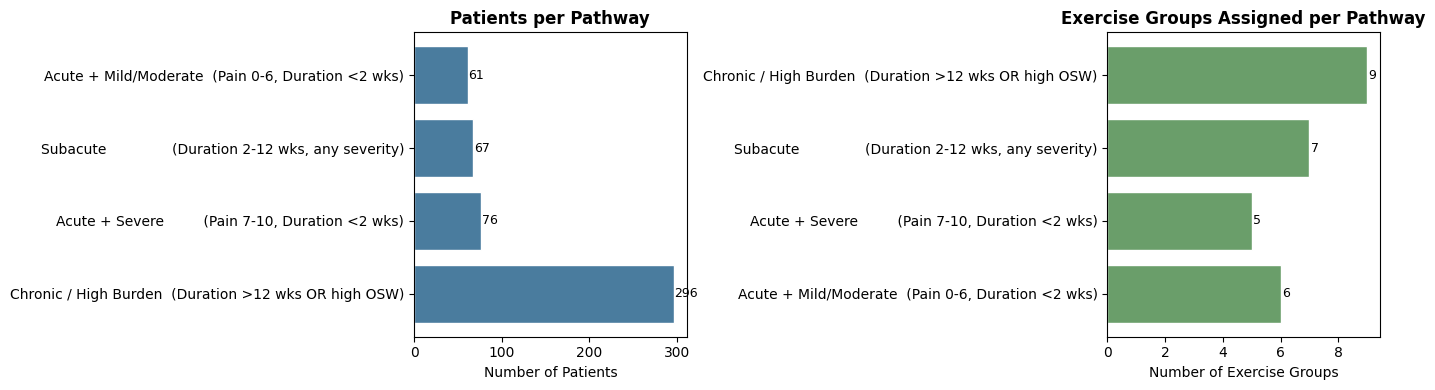

In [5]:
# KPI charts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

labels = [PATHWAY_LABELS[p] for p in pathway_counts.index]
axes[0].barh(labels, pathway_counts.values, color="#4a7c9e", edgecolor="white")
axes[0].set_title("Patients per Pathway", fontweight="bold")
axes[0].set_xlabel("Number of Patients")
for i, v in enumerate(pathway_counts.values):
    axes[0].text(v+1, i, str(v), va="center", fontsize=9)

group_counts = {PATHWAY_LABELS[k]: len(v) for k, v in PATHWAY_EXERCISES.items()}
axes[1].barh(list(group_counts.keys()), list(group_counts.values()), color="#6a9e6a", edgecolor="white")
axes[1].set_title("Exercise Groups Assigned per Pathway", fontweight="bold")
axes[1].set_xlabel("Number of Exercise Groups")
for i, v in enumerate(group_counts.values()):
    axes[1].text(v+0.05, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("kpi_scoreboard.png", dpi=150, bbox_inches="tight")
plt.show()

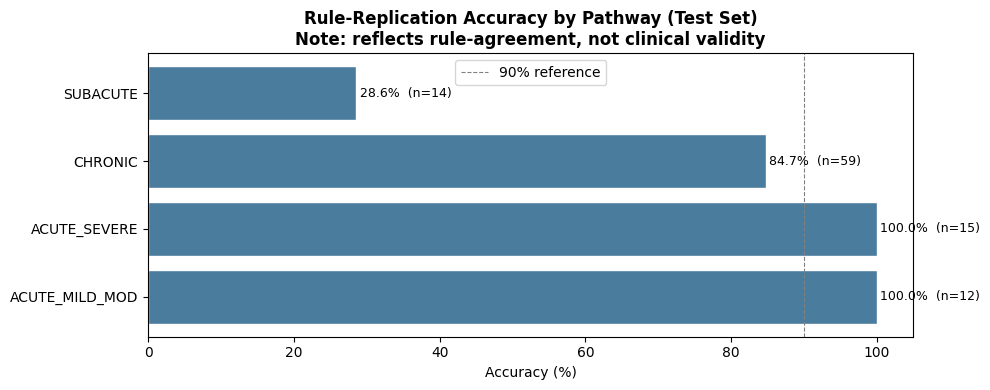

In [6]:
# Prediction accuracy by pathway

acc_by_pathway = (
    predictions.groupby("recommended_pathway")["prediction_correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Accuracy", "count": "N"})
    .reset_index()
)
acc_by_pathway["Accuracy_pct"] = acc_by_pathway["Accuracy"] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(acc_by_pathway["recommended_pathway"],
        acc_by_pathway["Accuracy_pct"],
        color="#4a7c9e", edgecolor="white")
ax.set_title("Rule-Replication Accuracy by Pathway (Test Set)\n"
             "Note: reflects rule-agreement, not clinical validity",
             fontweight="bold")
ax.set_xlabel("Accuracy (%)")
ax.axvline(x=90, color="gray", linestyle="--", linewidth=0.8, label="90% reference")
for i, row in acc_by_pathway.iterrows():
    ax.text(row["Accuracy_pct"] + 0.5, i,
            f"{row['Accuracy_pct']:.1f}%  (n={int(row['N'])})",
            va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("accuracy_by_pathway.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Limitations & scaling roadmap

print("""
POC Limitations & Scaling Roadmap
====================================

── Current Limitations ──────────────────────────────────────────

1. Rule-derived labels
   Model accuracy reflects agreement with our own rule logic,
   NOT predictive validity against real patient outcomes.

2. Three-variable rule engine
   Pathways assigned using pain_duration_weeks,
   pain_severity_score_0_10, and osw_baseline_percent_disability only.
   Clinically relevant factors such as psychosocial status, imaging
   findings, and prior treatment history are not yet included.

3. No outcome validation
   No follow-up data exists. The model cannot confirm whether
   assigned pathways led to recovery, pain reduction, or
   return to work.

4. Red-flag screening gap
   patient_intake does not include red_flag_present (Boolean).
   This must be added before any clinical deployment.

5. Equity analysis is descriptive only
   Statistical bias testing requires larger real-world samples.

── Scaling Roadmap: From POC to Clinical Validation ─────────────

Phase 2 — HITL Validation (Next Step, 0-3 Months)
  Protocol:
    - Export 50-75 edge cases from patient_intake
      (OSW > 40%, OR pain duration 1.5-2.5 wks,
       OR pain score 6-7 — cases where rules are least certain)
    - Licensed PT reviews each case blind to rule-assigned labels
    - PT assigns pathway based on clinical judgment
    - Measure rule-vs-PT agreement using Cohen's Kappa
    - Cases of disagreement used to refine rule thresholds
    - Accuracy metric reframed as clinical-expert-agreement
  Expected outcome:
    Converts model from "learned our rules" to
    "validated against licensed PT clinical judgment"

Phase 3 — Outcome Data Infrastructure (3-6 Months)
  - Collect real intake + 6/12-week follow-up OSW and pain scores
  - Outcome label: OSW improvement >= 20 points OR
    >= 50% pain score reduction
  - Add progression pathway logic to rule engine
  - Requires IRB approval and real user onboarding
  - Re-train model on independent clinical outcome labels
  - Accuracy metric reframed as true clinical predictive validity

Phase 4 — Multi-Clinic Deployment (12-24 Months)
  - Add red_flag_present to intake form
  - Expand feature set: psychosocial factors, prior treatment
    history, imaging findings
  - Deploy across multiple clinic locations with outcome monitoring,
    clinician feedback loops, and continuous model retraining
  - Equity monitoring dashboards to detect disparate pathway
    assignment rates across demographic subgroups
  - Go/no-go threshold: >= 85% agreement with PT triage
    on real patient sample before clinical pilot
  - IRB approval and clinical governance review required

── Summary ──────────────────────────────────────────────────────

  Current POC proves:   Rule logic is consistent and automatable
  Phase 2 will prove:   Logic aligns with licensed PT judgment
  Phase 3 will prove:   Model predicts real patient outcomes
  Phase 4 delivers:     Clinically deployable recommendation system
""")


POC Limitations & Scaling Roadmap

── Current Limitations ──────────────────────────────────────────

1. Rule-derived labels
   Model accuracy reflects agreement with our own rule logic,
   NOT predictive validity against real patient outcomes.

2. Three-variable rule engine
   Pathways assigned using pain_duration_weeks,
   pain_severity_score_0_10, and osw_baseline_percent_disability only.
   Clinically relevant factors such as psychosocial status, imaging
   findings, and prior treatment history are not yet included.

3. No outcome validation
   No follow-up data exists. The model cannot confirm whether
   assigned pathways led to recovery, pain reduction, or
   return to work.

4. Red-flag screening gap
   patient_intake does not include red_flag_present (Boolean).
   This must be added before any clinical deployment.

5. Equity analysis is descriptive only
   Statistical bias testing requires larger real-world samples.

── Scaling Roadmap: From POC to Clinical Validation ────────

In [8]:
# Export final output to BigQuery

from google.cloud.bigquery import LoadJobConfig, WriteDisposition

job_config = LoadJobConfig(write_disposition=WriteDisposition.WRITE_TRUNCATE, autodetect=True)
job = client.load_table_from_dataframe(
    patient_output, f"{PROJECT_ID}.{DATASET}.patient_exercise_output", job_config=job_config
)
job.result()
print(f"Exported {len(patient_output)} rows → patient_exercise_output")
print()
print("All BigQuery tables in dataset:")
for table in client.list_tables(f"{PROJECT_ID}.{DATASET}"):
    print(f"  {table.table_id}")

Exported 27497 rows → patient_exercise_output

All BigQuery tables in dataset:
  exercises
  ml_predictions
  model_predictions
  patient_exercise_output
  patient_intake
  patient_pathways
  v_equity_metrics
  v_exercise_coverage
  v_kpi_scoreboard
  v_model_predictions
  v_pathway_distribution


# Output Note

The `patient_output` table joins rule-assigned pathway labels to exercise
recommendations. All pathway assignments originate from the rule engine
in Notebook 03 — they are not independently validated clinical predictions.
This output is suitable for POC demonstration and grant review purposes only.